# 04 - Analisis bivariado y correlaciones

**Responsable principal:** José Donado

**Actividad de la guia:** 4c (cruce de variables importantes) y parte de *Analisis Exploratorio* (30 pts: correlaciones, outliers).

**Objetivo de este notebook:** cruzar las variables que mas puedan explicar el problema (longitud de secuencia, longitud de frase, participante, landmarks faltantes). Independiente de 01/02/03/05.

In [ ]:

import sys
sys.path.append("..")

# Importar las utilidades del equipo
from src import data_loading as dl
train_df = dl.load_train_index()

# Solo para revisar las filas
train_df.head()

,path,file_id,sequence_id,participant_id,phrase
0,train_landmarks/5414471.parquet,5414471,1816796431,217,3 creekhouse
1,train_landmarks/5414471.parquet,5414471,1816825349,107,scales/kuhaylah
2,train_landmarks/5414471.parquet,5414471,1816909464,1,1383 william lanier
3,train_landmarks/5414471.parquet,5414471,1816967051,63,988 franklin lane
4,train_landmarks/5414471.parquet,5414471,1817123330,89,6920 northeast 661st road


Phrase se refiere a la traducción de la frase expresada en señas, el id del paricipante es único, al igual que la secuencia hecha para cada archivo. Por último tenemos la dirección del archivo parquet con las coordenadas.

In [7]:
from src import config

#la ruta de la primera muestra
sample_path = dl.landmark_path(config.SAMPLE_LANDMARK_PATHS[0])

#  DataFrame de coordenadas
sample_landmarks = dl.load_landmarks(sample_path)

# Ver las dimensiones (filas y columnas)
print(sample_landmarks.shape)


(161461, 1630)


In [13]:
sample_landmarks.head()

,frame,x_face_0,x_face_1,x_face_2,x_face_3,x_face_4,x_face_5,x_face_6,x_face_7,x_face_8,...,z_right_hand_11,z_right_hand_12,z_right_hand_13,z_right_hand_14,z_right_hand_15,z_right_hand_16,z_right_hand_17,z_right_hand_18,z_right_hand_19,z_right_hand_20
sequence_id,,,,,,,,,,,,,,,,,,,,,
1975433633,0,0.578892,0.578482,0.582906,0.572686,0.579030,0.582115,0.591430,0.498995,0.595773,...,-0.253687,-0.291687,-0.123892,-0.195255,-0.249135,-0.284375,-0.125050,-0.187797,-0.224827,-0.249662
1975433633,1,0.577563,0.578528,0.582916,0.572760,0.579090,0.582197,0.591687,0.497613,0.596104,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975433633,2,0.576181,0.576949,0.581346,0.572293,0.577725,0.581191,0.591550,0.497113,0.596477,...,-0.233556,-0.267114,-0.116145,-0.179053,-0.223861,-0.253004,-0.122090,-0.173169,-0.200727,-0.219106
1975433633,3,0.575575,0.577569,0.581769,0.572443,0.578289,0.581652,0.591728,0.496759,0.596573,...,-0.190909,-0.218471,-0.093956,-0.149982,-0.188452,-0.211573,-0.102759,-0.147642,-0.168562,-0.180578
1975433633,4,0.577907,0.577628,0.582295,0.572930,0.578345,0.581873,0.592467,0.498170,0.597383,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

sample_landmarks.describe()

,frame,x_face_0,x_face_1,x_face_2,x_face_3,x_face_4,x_face_5,x_face_6,x_face_7,x_face_8,...,z_right_hand_11,z_right_hand_12,z_right_hand_13,z_right_hand_14,z_right_hand_15,z_right_hand_16,z_right_hand_17,z_right_hand_18,z_right_hand_19,z_right_hand_20
count,161461.000000,160278.000000,160278.000000,160278.000000,160278.000000,160278.000000,160278.000000,160278.000000,160278.000000,160278.000000,...,73394.000000,73394.000000,73394.000000,73394.000000,73394.000000,73394.000000,73394.000000,73394.000000,73394.000000,73394.000000
mean,104.867541,0.554182,0.548478,0.551414,0.536308,0.548015,0.548732,0.551513,0.444876,0.551947,...,-0.135173,-0.144074,-0.067872,-0.128156,-0.138056,-0.131727,-0.086140,-0.131659,-0.135321,-0.128832
std,86.207191,0.129534,0.126287,0.128008,0.127805,0.126163,0.126821,0.129227,0.134529,0.130194,...,0.070175,0.076910,0.046918,0.062506,0.067768,0.074496,0.049549,0.061519,0.066956,0.073019
min,0.000000,0.103906,0.107426,0.106770,0.087026,0.106714,0.104606,0.097967,-0.068946,0.085629,...,-0.804502,-0.911767,-0.452172,-0.646407,-0.789027,-0.892902,-0.471836,-0.653871,-0.763084,-0.848687
25%,41.000000,0.489872,0.485121,0.487680,0.472735,0.484261,0.484653,0.486007,0.381312,0.485465,...,-0.166090,-0.177454,-0.088966,-0.157679,-0.169352,-0.165617,-0.109835,-0.161745,-0.167367,-0.163408
50%,86.000000,0.572730,0.566025,0.569351,0.554663,0.565580,0.566387,0.569752,0.468610,0.570553,...,-0.121772,-0.129739,-0.058184,-0.117250,-0.125355,-0.118194,-0.076272,-0.120762,-0.123404,-0.116560
75%,146.000000,0.639833,0.630259,0.635003,0.619101,0.629602,0.631083,0.636369,0.533060,0.637612,...,-0.089064,-0.092906,-0.036033,-0.086171,-0.092268,-0.080486,-0.051808,-0.089323,-0.089033,-0.077901
max,750.000000,1.022021,1.026810,1.023538,0.997192,1.024715,1.018555,1.002975,0.871772,1.005253,...,0.253719,0.281694,0.152119,0.191191,0.229842,0.270752,0.139569,0.167341,0.215793,0.253798


In [3]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import data_loading as dl

sns.set_theme(style="whitegrid")


## 1. Longitud de secuencia vs. longitud de frase

Dispersion + correlacion entre el numero de frames de la secuencia y el numero de caracteres de la frase deletreada. Es razonable esperar relacion positiva (frases mas largas -> secuencias mas largas).

In [ ]:
#longitud de la frase (número de caracteres)
# nueva columna llamada 'phrase_len' en train_df
train_df["phrase_len"] = train_df["phrase"].str.len()

# por otro lado: la longitud de la secuencia (número de frames)
# Agrupamos por el índice (que es el sequence_id) y contamos las filas
seq_lengths = sample_landmarks.groupby(sample_landmarks.index).size().reset_index(name="seq_len")
seq_lengths = seq_lengths.rename(columns={"sequence_id": "sequence_id"}) # Asegurar el nombre para el merge

train_df.loc[0:10, "phrase_len"] # muestra de que da la phraselen

0     12
1     15
2     19
3     17
4     25
5     15
6     22
7     20
8     12
9     25
10    16
Name: phrase_len, dtype: int64

Con este código simplemente se creó una nueva columna en el dataset de entrenamiento que indica la longitud de la frase

Correlación de Pearson (r): 0.5979


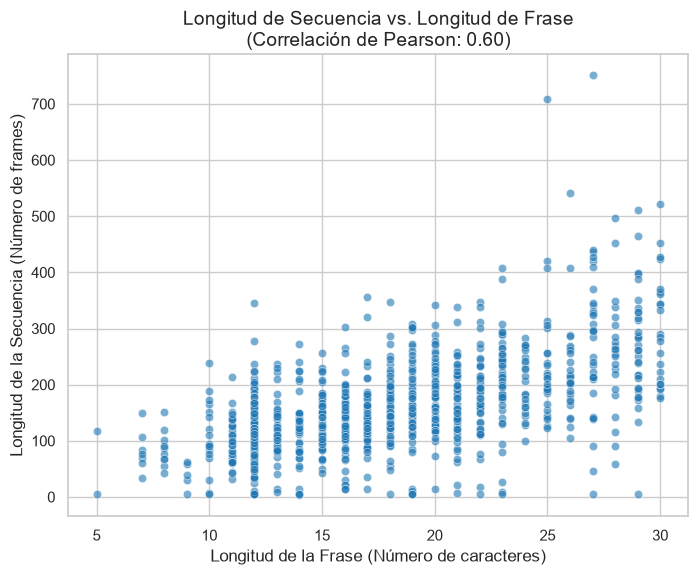

In [21]:
#Unir ambos DataFrames usando el 'sequence_id'
merged_df = pd.merge(train_df, seq_lengths, on="sequence_id", how="inner")

# correlación de Pearson
correlacion = merged_df["phrase_len"].corr(merged_df["seq_len"])
print(f"Correlación de Pearson (r): {correlacion:.4f}")

# gráfico de dispersión con Seaborn
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=merged_df, x="phrase_len", y="seq_len", alpha=0.6, color="tab:blue", ax=ax)
ax.set_title(f"Longitud de Secuencia vs. Longitud de Frase\n(Correlación de Pearson: {correlacion:.2f})", fontsize=14)
ax.set_xlabel("Longitud de la Frase (Número de caracteres)", fontsize=12)
ax.set_ylabel("Longitud de la Secuencia (Número de frames)", fontsize=12)

# IMPORTANTEEEEE Guardar la figura en la carpeta estructurada del proyecto
fig.savefig(config.ROOT_DIR / "reports" / "figures" / "dispersion_longitudes.png", dpi=150, bbox_inches="tight")
plt.show()

Es evidente que existe una correlación positiva entre la longitud de frase y la secuencia, dado que entre más larga sea la frase mayor será el número de frames.

In [27]:

pearson_r = merged_df["phrase_len"].corr(merged_df["seq_len"])
print(f"El coeficiente de correlación de Pearson es: {pearson_r:.4f}")

El coeficiente de correlación de Pearson es: 0.5979


Lo visto en el gráfico se confirma con el coeficiente de Pearson, dado a que se tiene un 60% de relación positiva aproximadamente. 

## 2. Variables por participante

TODO: boxplot de longitud de secuencia (o de frase) agrupado por `participant_id` para ver si hay participantes que deletrean mas rapido/lento o con frases mas largas.

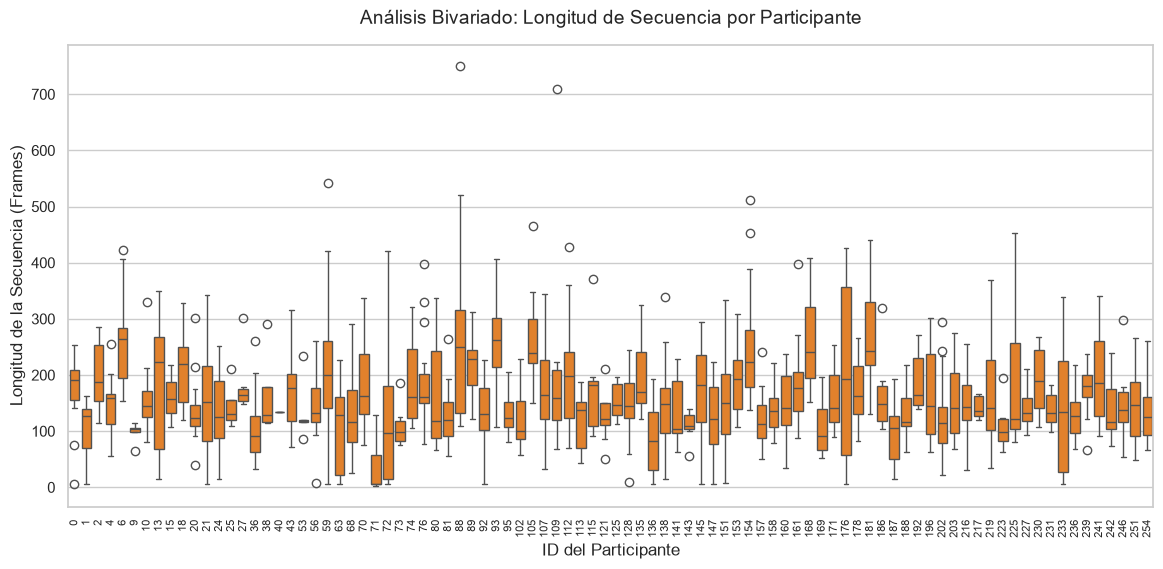

In [24]:
# que quepan todos los IDs
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=merged_df, x="participant_id", y="seq_len", color="tab:orange", ax=ax)
ax.set_title("Análisis Bivariado: Longitud de Secuencia por Participante", fontsize=14, pad=15)
ax.set_xlabel("ID del Participante", fontsize=12)
ax.set_ylabel("Longitud de la Secuencia (Frames)", fontsize=12)

plt.xticks(rotation=90, fontsize=8) 

# Guardar la figura en la carpeta estructurada del proyecto
fig.savefig(config.ROOT_DIR / "reports" / "figures" / "boxplot_participantes.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Landmarks faltantes vs. longitud de secuencia

TODO: ver si las secuencias mas largas tienden a tener mas (o menos) proporcion de landmarks faltantes -- podria indicar fatiga, salida de camara, etc.

In [ ]:
# Calcular el promedio de valores nulos (NaNs) por cada cuadro en la secuencia
# isna().sum(axis=1) cuenta los NaNs por frame. Luego agrupamos por sequence_id.
nan_counts = sample_landmarks.isna().sum(axis=1).groupby(sample_landmarks.index).mean().reset_index(name="promedio_nans")
nan_counts = nan_counts.rename(columns={"sequence_id": "sequence_id"})

# unir información con la longitud de la secuencia
missing_bivariado = pd.merge(seq_lengths, nan_counts, on="sequence_id", how="inner")

pearson_r = missing_bivariado["seq_len"].corr(missing_bivariado["promedio_nans"])

print(f"El coeficiente de correlación de Pearson es: {pearson_r:.4f}")

El coeficiente de correlación de Pearson es: -0.1883


Con un coeficiente relativamente pequeño en escala y negativo se concluye que sí existe una relación negativa entre los landmarks faltantes y la longitud de secuencia.

Para entender la relación, antes hay que recordarse que un landmark representa un punto físico de lo que la cámara puede captar y es interpretado por MediaPipe. La mayoría de puntos se concentran en el rostro (468 puntos), seguido de 33 en la postura y solo 21 puntos en la mano. Si la falta de puntos es considerable, es conspicuo que la secuencia va a ser de menor longitud. Ahora, también se puede dar que una longitud de secuencia sea larga pero sea futil si no capta a las manos porque simplemente no te dice algo.

Por ello, a menor puntos de referencia, menor longitud de secuencia.

## 4. Matriz de correlacion

TODO: correlacion entre todas las variables numericas agregadas disponibles (heatmap).

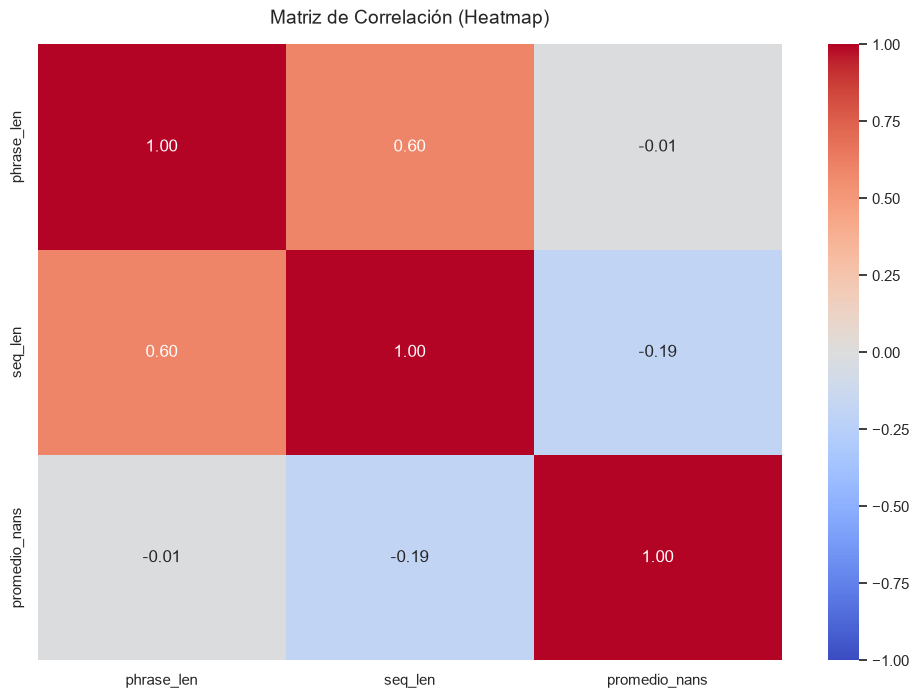

In [ ]:
# Unificar las variables numéricas clave en un solo DataFrame

df_numericas = pd.merge(train_df[["sequence_id", "phrase_len"]], seq_lengths, on="sequence_id")
df_numericas = pd.merge(df_numericas, nan_counts, on="sequence_id")
# (excluimos IDs)
columnas_analisis = ["phrase_len", "seq_len", "promedio_nans"]
matriz_corr = df_numericas[columnas_analisis].corr()


fig, ax = plt.subplots(figsize=(12, 8))

# annot=True muestra los números dentro de los cuadros
# vmin=-1 y vmax=1 aseguran que la escala de colores sea la correcta para Pearson
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax, fmt=".2f")
# Etiquetas y título
ax.set_title("Matriz de Correlación (Heatmap)", fontsize=14, pad=15)




# Guardar la figura en la carpeta del proyecto
fig.savefig(config.ROOT_DIR / "reports" / "figures" / "heatmap_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

Esto facilita la visualización de las correlaciones. Extrañamente, la correlacion entre la longitud de frase y el promedio de información perdida es baja. Por ende, no se tomará en cuenta al relacionarlas.

## 5. Outliers

identificar secuencias atipicas (demasiado largas/cortas, frases anomalamente largas) y proponer una explicacion (error de captura, frase real muy larga, etc.).
Para ello, se utilizó el análisis de intercuartiles para definir los límites de puntos atípicos.

Secalcularon los limites para los frames y la longitud de frase, luego se ven los top infractores.

In [ ]:
# Definir una función para calcular los límites de los outliers usando IQR
def obtener_limites(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

lim_inf_seq, lim_sup_seq = obtener_limites(df_numericas, "seq_len")
lim_inf_phrase, lim_sup_phrase = obtener_limites(df_numericas, "phrase_len")

#outliers: secuencias que caen fuera de los límites normales
outliers = df_numericas[
    (df_numericas["seq_len"] < lim_inf_seq) | (df_numericas["seq_len"] > lim_sup_seq) |
    (df_numericas["phrase_len"] < lim_inf_phrase) | (df_numericas["phrase_len"] > lim_sup_phrase)
]


print(f"Se encontraron {len(outliers)} secuencias atípicas de un total de {len(df_numericas)}.")
print(f"Límites normales de frames: {lim_inf_seq:.1f} a {lim_sup_seq:.1f}")
print(f"Límites normales de caracteres: {lim_inf_phrase:.1f} a {lim_sup_phrase:.1f}\n")

outliers.sort_values(by="seq_len", ascending=False).head(10)

Se encontraron 28 secuencias atípicas de un total de 998.
Límites normales de frames: -47.6 a 359.4
Límites normales de caracteres: -3.0 a 37.0



,sequence_id,phrase_len,seq_len,promedio_nans
37,1976808237,27,751,163.929427
826,2003109217,25,709,119.602257
259,1983592273,26,542,68.346863
568,1994265137,30,521,99.760077
887,2004864487,29,511,94.438356
778,2001394023,28,497,87.338028
355,1986632689,29,465,75.870968
702,1999024841,28,452,63.139381
706,1999135549,30,452,153.278761
195,1981453996,27,440,75.743182


Pregunta: ¿ por qué hay números negativos en los límites de frames y caracteres?
Se debe a la forma en la que se calculan los límites inferiores de intercuartiles: Q1 - 1.5 *IQR.
Sin embargo, se ha de considerar que el límite inferior para ambas variables es de 0. Así, los límites normales son los que no superan los 359.4 frames y los 37 caracteres. Es decir, frases pequeñas.